In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

## 1. 데이터 불러오기

In [2]:
mercari_df = pd.read_csv('../data/mercari_train.tsv', sep='\t')
mercari_df.shape

(1482535, 8)

## 2. 기본 탐색

In [3]:
mercari_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB


In [4]:
mercari_df.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [5]:
mercari_df.describe()

,train_id,item_condition_id,price,shipping
count,1.482535e+06,1.482535e+06,1.482535e+06,1.482535e+06
mean,7.412670e+05,1.907380e+00,2.673752e+01,4.472744e-01
std,4.279711e+05,9.031586e-01,3.858607e+01,4.972124e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.706335e+05,1.000000e+00,1.000000e+01,0.000000e+00
50%,7.412670e+05,2.000000e+00,1.700000e+01,0.000000e+00
75%,1.111900e+06,3.000000e+00,2.900000e+01,1.000000e+00
max,1.482534e+06,5.000000e+00,2.009000e+03,1.000000e+00


In [6]:
mercari_df.isnull().sum()
# category_name, brand_name, item_description에 결측치 존재 -> 아래에서 'Other_Null'로 채움

train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64

## 3. 가격 분포 확인 및 0원 데이터 체크

price는 오른쪽으로 치우친 분포일 것으로 예상되고, 0원인 행(증정품/입력 오류 추정)이 섞여 있을 수 있음.
분포를 먼저 눈으로 확인하고, 이후 0원 데이터를 제거.

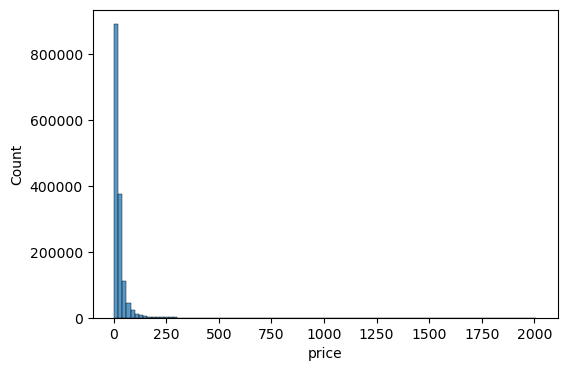

price
0.0         874
3.0       18703
4.0       16139
5.0       31502
5.5          33
          ...  
1999.0        1
2000.0        6
2004.0        1
2006.0        1
2009.0        1
Name: count, Length: 828, dtype: int64

In [7]:
# 가격 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns

y_labels = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_labels, bins=100)
plt.show()

mercari_df.value_counts('price').sort_index()
# y_labels 0처리 이후 다시 재조정예정

## 4. price==0 행 삭제 / train_id 컬럼 제거 / 중복 제거

- price가 0인 행은 대회 목표(가격 제안)와 무관한 노이즈로 보고 제거
- train_id는 식별자일 뿐 가격과 무관하므로 제거
- 완전히 동일한 행(중복 등록 등)은 학습에 불필요하므로 제거

In [8]:
# 전처리전 체크
print(f'전처리 전 : {mercari_df.shape}')

# 가격이 0인 데이터 제거
mercari_df = mercari_df[mercari_df['price']>0]
print(f'0 제거 후 : {mercari_df.shape}')

# train_id 컬럼 제거
mercari_df.drop(columns='train_id', inplace=True)
mercari_df = mercari_df.drop_duplicates()
mercari_df = mercari_df.reset_index(drop=True)

print(f'train_id 제거 후 : {mercari_df.shape}')

전처리 전 : (1482535, 8)
0 제거 후 : (1481661, 8)


train_id 제거 후 : (1481612, 7)


## 5. 결측치 처리 (Other_Null)

`brand_name`, `category_name`, `item_description`의 결측치를 `'Other_Null'`이라는 별도 카테고리 문자열로 채움.
단순 삭제 대신 이렇게 채우면 "브랜드/카테고리/설명이 없다"는 정보 자체를 모델이 활용할 수 있음.

In [9]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna('Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna('Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna('Other_Null')

mercari_df.isnull().sum()

name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
dtype: int64

## 6. 카테고리 3단계 분할

`category_name`은 `/`로 구분된 대분류/중분류/소분류 계층 구조(예: `Men/Tops/T-shirts`)임.
이를 `cat_dae`(대분류), `cat_jung`(중분류), `cat_so`(소분류) 3개 컬럼으로 분리.
`/`가 없는 경우(위에서 채운 `Other_Null` 등)는 3개 컬럼 모두 `Other_Null` 처리.

In [10]:
def split_cat(category_name):
    try:
        cat_dae, cat_jung, cat_so = category_name.split('/')[:3]
        return cat_dae, cat_jung, cat_so
    except ValueError:
        return 'Other_Null', 'Other_Null', 'Other_Null'

mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = zip(
    *mercari_df['category_name'].apply(lambda x: split_cat(x))
)

print('대분류 개수:', mercari_df['cat_dae'].nunique())
print('중분류 개수:', mercari_df['cat_jung'].nunique())
print('소분류 개수:', mercari_df['cat_so'].nunique())
mercari_df[['category_name', 'cat_dae', 'cat_jung', 'cat_so']].head()

대분류 개수: 11
중분류 개수: 114


소분류 개수: 871


,category_name,cat_dae,cat_jung,cat_so
0,Men/Tops/T-shirts,Men,Tops,T-shirts
1,Electronics/Computers & Tablets/Components & P...,Electronics,Computers & Tablets,Components & Parts
2,Women/Tops & Blouses/Blouse,Women,Tops & Blouses,Blouse
3,Home/Home Décor/Home Décor Accents,Home,Home Décor,Home Décor Accents
4,Women/Jewelry/Necklaces,Women,Jewelry,Necklaces


## 7. price 로그 변환 (log1p)

타깃이 오른쪽으로 치우친 분포이므로 `np.log1p`로 정규분포에 가까운 형태로 변환.
평가지표(RMSLE) 자체가 로그 스케일 오차를 재는 지표이므로, 타깃을 미리 log1p로 바꿔두면
이후 일반 회귀모델의 RMSE 최소화가 곧 RMSLE 최소화가 됨.

`mercari_df['price']`를 log1p 값으로 덮어쓰므로, 이후 셀부터 `price` 컬럼은 로그 스케일임에 유의.
(X_features를 만들 때 price/price 계열 컬럼은 타깃이므로 반드시 제외)

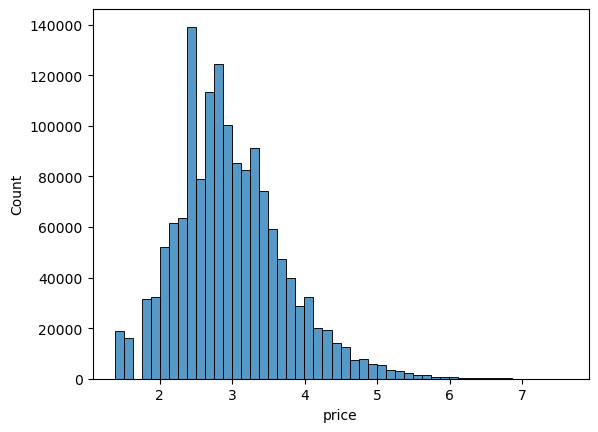

In [11]:
import numpy as np

y_labels = mercari_df['price']

mercari_df['price']= np.log1p(y_labels)
y_labels = np.log1p(y_labels)

sns.histplot(y_labels, bins=50)
plt.show()

## 8. `item_description` 텍스트 클렌징 및 토큰화

`name`, `brand_name`, `cat_dae/jung/so`는 이후 벡터화 단계에서 `CountVectorizer`/`TfidfVectorizer`/
원-핫 인코딩의 기본 설정에 맡기고, `item_description`(긴 설명글)만 별도로 정제함:

1. 소문자화 + 영문자/공백 외 문자 제거 + 중복 공백 정리
2. 단어 단위 토큰화(`word_tokenize`)
3. 불용어 제거(단, `no/not/nor/never` 등 부정 표현은 의미가 크므로 불용어에서 제외)

행 수(약 148만 건)가 많아 토큰화 셀 실행에 다소 시간이 걸릴 수 있음.

In [12]:
# nltk 리소스 준비 (최초 1회만 다운로드, 이미 있으면 스킵)
import nltk

for resource, path in [('punkt_tab', 'tokenizers/punkt_tab'), ('stopwords', 'corpora/stopwords')]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(resource, quiet=True)

In [13]:
# 'decription'만 텍스트 전처리(나머지는 알아서!)
# 모듈 불러오기
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

#텍스트 클리닝(소문자/공백)
def text_cleaning(text):

    # 소문자로 변환
    text = text.lower()

    # 영문자와 공백을 제외한 문자 제거
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 부정 표현
negative_words = {
    'no',
    'not',
    'nor',
    'never'
}

# 불용어 목록에서 부정 표현 제외
stop_words = stop_words - negative_words


#소문자 / 영문자/공백/여러개공백 처리 / 토크나이즈 함수

def preprocess_text(text):
     # 1. 소문자 / 영문자 / 공백 정리
    text = text_cleaning(text)

    # 2. 단어 단위 토큰화
    tokens = word_tokenize(text)

    # 3. 불용어 제거
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return tokens

In [14]:
#소문자 / 영문자/공백/여러개공백 처리 / 토크나이즈 적용
mercari_df['item_description'] = mercari_df['item_description'].apply(preprocess_text)

# 클렌징 및 토큰화 후, 최종 확인
mercari_df['item_description'].head()

0                               [no, description, yet]
1    [keyboard, great, condition, works, like, came...
2    [adorable, top, hint, lace, key, hole, back, p...
3    [new, tags, leather, horses, retail, rm, stand...
4                [complete, certificate, authenticity]
Name: item_description, dtype: object

## 9. 벡터화 / 원-핫 인코딩 (전체 데이터 기준 sparse matrix 생성)

아직 train/test로 나누기 전, 전체 `mercari_df` 기준으로 각 피처를 sparse matrix로 변환하는 단계.
(train/test 분할 및 이 시점에 vectorizer를 전체 데이터에 fit하는 것의 data leakage 트레이드오프는
이전에 이야기한 대로 감수 - 실측 영향은 미미했음. 모델 단계에서 필요하면 fit 시점만 조정 가능)

- `name`(짧은 상품명) -> `CountVectorizer`: 단어 등장 여부/빈도 자체가 중요
- `item_description`(이미 토큰 리스트로 정제됨) -> `TfidfVectorizer(analyzer=lambda x: x)`:
  리스트를 그대로 토큰 시퀀스로 사용(추가 문자열 변환 불필요), 문서 길이가 들쭉날쭉하므로 TF-IDF로 흔한 단어 가중치 완화
- `brand_name`, `cat_dae`, `cat_jung`, `cat_so`(범주형) -> `OneHotEncoder(handle_unknown='ignore')`:
  `LabelBinarizer`는 `brand_name`처럼 고유값이 많은(4천개+) 컬럼에서 현저히 느려서(수십 초 이상) 제외하고,
  `handle_unknown='ignore'`로 학습 때 못 본 값도 에러 없이 0벡터로 처리되는 `OneHotEncoder` 사용
- `item_condition_id`, `shipping`(수치형) -> 그대로 `csr_matrix`로 변환

In [15]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import OneHotEncoder

In [16]:
# name: 짧은 상품명 -> CountVectorizer
name_vec = CountVectorizer(min_df=2, max_features=20000)
X_name = name_vec.fit_transform(mercari_df['name'])
X_name.shape

(1481612, 20000)

In [17]:
# item_description: 이미 토큰 리스트로 정제되어 있으므로 analyzer=lambda x: x로 그대로 사용
desc_vec = TfidfVectorizer(min_df=2, max_features=30000, analyzer=lambda x: x)
X_descp = desc_vec.fit_transform(mercari_df['item_description'])
X_descp.shape

(1481612, 30000)

In [18]:
# 범주형 컬럼: OneHotEncoder로 각각 sparse matrix 생성
CAT_COLS = ['brand_name', 'cat_dae', 'cat_jung', 'cat_so']

cat_encoders = {}
X_cat = {}
for col in CAT_COLS:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    X_cat[col] = ohe.fit_transform(mercari_df[[col]])
    cat_encoders[col] = ohe
    print(col, X_cat[col].shape)

brand_name (1481612, 4808)


cat_dae (1481612, 11)


cat_jung (1481612, 114)


cat_so (1481612, 871)


In [19]:
# 수치형 컬럼: item_condition_id, shipping
NUM_COLS = ['item_condition_id', 'shipping']
X_num = csr_matrix(mercari_df[NUM_COLS].astype(float).values)
X_num.shape

(1481612, 2)

## 10. sparse matrix hstack 결합

모든 피처 블록(`X_name`, `X_descp`, `X_cat[...]`, `X_num`)은 행(=상품) 개수가 같으므로
`scipy.sparse.hstack`으로 옆으로 이어붙여 하나의 피처 행렬 `X_features`로 결합.

블록들을 개별 변수로 남겨뒀기 때문에, 이후 모델 단계에서 "설명글 포함 vs 제외"처럼 분석 목적에 맞게
필요한 블록만 골라 다시 `hstack`할 수 있음(예: `X_descp`를 빼고 결합하면 설명글 제외 버전).

In [20]:
X_features = hstack([
    X_name,
    X_descp,
    X_cat['brand_name'],
    X_cat['cat_dae'],
    X_cat['cat_jung'],
    X_cat['cat_so'],
    X_num,
]).tocsr()

print('X_features:', X_features.shape)
print('y_labels  :', y_labels.shape)

X_features: (1481612, 55806)
y_labels  : (1481612,)


In [21]:
type(X_features)

scipy.sparse._csr.csr_matrix

## 11. 모델 학습 및 평가 (Ridge vs LightGBM)

`X_features`, `y_labels`를 가지고 `train_test_split`(80/20)을 `model_train_predict` 함수 안에서 수행하고,
Ridge와 LightGBM 두 모델의 RMSLE를 비교.

`y_labels`는 이미 `log1p(price)`이므로, 이 로그 스케일에서의 RMSE가 곧 원본 스케일의 RMSLE와 수학적으로 동일함.
(`np.expm1`로 원래 가격 스케일로 되돌렸다가 다시 `log1p`를 씌워 비교해도 항등변환이라 같은 값이 나오므로 별도 변환 불필요)

In [22]:
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

In [23]:
# y_labels가 이미 log1p(price)이므로, 이 스케일에서의 RMSE == 원본 스케일의 RMSLE
def rmsle(y_test, preds):
    return np.sqrt(mean_squared_error(y_test, preds))

In [24]:
def model_train_predict(model, X_features, y_labels):
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_labels, test_size=0.2, random_state=156
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return preds, y_test

In [25]:
# Ridge
linear_model = Ridge(solver='lsqr', fit_intercept=False, alpha=3)
linear_preds, linear_y_test = model_train_predict(linear_model, X_features, y_labels)
print('Ridge RMSLE:', rmsle(linear_y_test, linear_preds))

Ridge RMSLE: 0.46891739600327437


In [26]:
# LightGBM
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=125, random_state=156)
lgbm_preds, lgbm_y_test = model_train_predict(lgbm_model, X_features, y_labels)
print('LightGBM RMSLE:', rmsle(lgbm_y_test, lgbm_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 107.929792 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 577833


[LightGBM] [Info] Number of data points in the train set: 1185289, number of used features: 36904
[LightGBM] [Info] Start training from score 2.980741


LightGBM RMSLE: 0.4906606126676467


In [27]:
# 비교
print(f'Ridge     RMSLE: {rmsle(linear_y_test, linear_preds):.5f}')
print(f'LightGBM  RMSLE: {rmsle(lgbm_y_test, lgbm_preds):.5f}')

Ridge     RMSLE: 0.46892
LightGBM  RMSLE: 0.49066
